In [44]:
from plot_functions import *
import joblib
import os

In [45]:
os.getcwd()

'/Users/ahabisaac/Projects/xai-concept-leakage'

In [46]:
dsprites_path = 'results/dsprites_dep_0_models'
tabulartoy_path = 'results/tabulartoy_25_10k_models'
crcem_path = 'results/tabulartoy_25_10k_models_crcem'
tabulartoy_acem_path = 'results/tabulartoy_25_10k_models_acem_shared_critic'
cub_path = 'results/cub_soft_0.01'
dsprites_acbm_path = 'results/dsprites_ACBM_shared_critic'
dsprites_sequential_path = 'results/dsprites_sequential_acbm'
dsprites_cem_path = 'results/dsprites_cem'
dsprites_acem_path = 'results/dsprites_acem_shared_critic'
tabulartoy_acbm_shared_path = 'results/tabulartoy_25_10k_models_acbm_shared_critic'
cub_acbm_shared_path = 'results/cub_acbm_shared_critic'
cub_cem_path = 'results/cub_cem'

In [47]:
def make_df(path):
    data_records = []
    
    # Define regex patterns to find the specific values in the filename
    # matches 'lam_c' followed by digits/dots
    lam_c_pattern = r"lam_c([0-9\.]+)"
    # matches 'split_' followed by digits
    split_pattern = r"split_([0-9]+)"  

    #if model == 'ACBM':
    for f_dir in os.listdir(path):
        model_path = os.path.join(path, f_dir)
            
        # Check if it's actually a directory
        if not os.path.isdir(model_path):
            continue

        for f in os.listdir(model_path):
            if 'results.joblib' in f:
                # 1. Extract Metadata using Regex
                lam_c_match = re.search(lam_c_pattern, f)
                split_match = re.search(split_pattern, f)
                
                # safely get values if matches are found
                lam_c_val = float(lam_c_match.group(1)) if lam_c_match else None
                split_val = int(split_match.group(1)) if split_match else None
                
                # 2. Load the actual result content
                result_content = joblib.load(os.path.join(model_path, f))
                
                # 3. Create a dictionary for this row
                row = {
                    'lam_c': lam_c_val,
                    'split': split_val,
                    'filename': f  # good to keep for debugging
                }
                
                # 4. Merge with result content
                # If result_content is a dict (e.g. {'acc': 0.5}), this adds those columns to the row
                if isinstance(result_content, dict):
                    row.update(result_content)
                else:
                    # If it's just a single number or object, store it in a generic column
                    row['result_obj'] = result_content
                
                data_records.append(row)

    # Convert list of dicts to DataFrame
    df = pd.DataFrame(data_records)
    # Assuming res_tabulartoy is your DataFrame
    df = df.copy()  # work on a copy to be safe
    
    if 'test_icl_average' in df.columns:
        if 'test_normalised_icl' not in df.columns:
            df['test_normalised_icl'] = df['test_icl_average']
        else:
            df['test_normalised_icl'] = df['test_normalised_icl'].fillna(df['test_icl_average'])

    if 'test_ctl_average' in df.columns:
        if 'test_normalised_ctl' not in df.columns:
            df['test_normalised_ctl'] = df['test_ctl_average']
        else:
            df['test_normalised_ctl'] = df['test_normalised_ctl'].fillna(df['test_ctl_average'])
    # Optional: Sort by lam_c and split for cleaner viewing
    if not df.empty:
        df = df.sort_values(by=['lam_c', 'split']).reset_index(drop=True)
    df = df[df['filename'] != 'results.joblib']
    return df

In [48]:
res_dsprites = make_df(dsprites_path)
res_dsprites_acbm = make_df(dsprites_acbm_path)
res_dsprites_sequential = make_df(dsprites_sequential_path)
res_dsprites_cem = make_df(dsprites_cem_path)
res_dsprites_acem = make_df(dsprites_acem_path)
res_tabulartoy = make_df(tabulartoy_path)
res_tabulartoy_acbm_shared = make_df(tabulartoy_acbm_shared_path)
res_crcem = make_df(crcem_path)
res_tabulartoy_acem = make_df(tabulartoy_acem_path)
res_cub = make_df(cub_path)
res_cub_acbm_shared = make_df(cub_acbm_shared_path)
res_cub_cem = make_df(cub_cem_path)

In [49]:
custom_palette = {
    'ACBM':   '#1f77b4',   # Blue
    'GN-CBM':    '#17becf',   # Cyan (shared critic / GRL)
    'SoftCBM': '#ff7f0e',   # Orange
    'HardCBM': '#2ca02c',   # Green
    'CRCEM':   '#d62728',   # Red
    'GN-CEM':  '#e377c2',   # Pink (shared critic CEM / GRL)
    'CEM':     '#9467bd',   # Purple
    'SeqCBM':  '#8c564b',   # Brown
    'Other':   '#7f7f7f'    # Grey
}

def get_model(f):
    if 'SeqCBM' in f: return 'SeqCBM'
    if 'ACEM' in f: return 'GN-CEM'
    if 'CRCEM' in f and 'shared_critic' in f: return 'GN-CEM'
    if 'CRCEM' in f: return 'CRCEM'
    if 'shared_critic' in f: return 'GN-CBM'
    if 'CRCBM' in f: return 'ACBM'
    if 'SoftCBM' in f: return 'SoftCBM'
    if 'Hard' in f: return 'HardCBM'
    if 'CEM' in f: return 'CEM'
    return 'Other'

def plot_bar_evaluation(df, models=None, model="ACBM", dataset_name="Dataset", save_dir='saved_charts'):
    df = df.copy()
    df['Model'] = df['filename'].apply(get_model)

    icl_str = 'test_normalised_icl' if ('test_normalised_icl' in df and not df['test_normalised_icl'].isna().any()) else 'test_icl_average'
    ctl_str = 'test_normalised_ctl' if ('test_normalised_ctl' in df and not df['test_normalised_ctl'].isna().any()) else 'test_ctl_average'

    metrics = [
        ('test_acc_y', 'Task Accuracy'),
        ('test_acc_c', 'Concept Accuracy'),
        (ctl_str, 'Norm. CTL (Leakage)'),
        (icl_str, 'Norm. ICL (Inter-leakage)')
    ]

    if models is None:
        comparision = 'CEM' if model in ('CRCEM',) else 'SoftCBM'
        models = [model, comparision]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    plot_df = df[df['Model'].isin(models)]

    for i, (col, title) in enumerate(metrics):
        ax = axes[i]

        barplot = sns.barplot(
            data=plot_df,
            x='lam_c',
            y=col,
            hue='Model',
            hue_order=models,
            palette=custom_palette,
            errorbar=None,
            ax=ax,
        )

        for container in barplot.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

        baselines = []

        hard_subset = df[df['Model'] == 'HardCBM'][col]
        if not hard_subset.empty:
            hard_val = hard_subset.mean()
            hard_std = hard_subset.std()
            ax.axhline(hard_val, color=custom_palette['HardCBM'], linestyle='--', label='HardCBM Baseline')
            ax.axhspan(hard_val - hard_std, hard_val + hard_std, color=custom_palette['HardCBM'], alpha=0.15)
            ax.axhline(hard_val + hard_std, color=custom_palette['HardCBM'], linestyle='--', alpha=0.5, linewidth=1)
            ax.axhline(hard_val - hard_std, color=custom_palette['HardCBM'], linestyle='--', alpha=0.5, linewidth=1)
            baselines.append((hard_val, custom_palette['HardCBM'], f'{hard_val:.3f}'))

        seq_subset = df[df['Model'] == 'SeqCBM'][col]
        if not seq_subset.empty:
            seq_val = seq_subset.mean()
            seq_std = seq_subset.std()
            ax.axhline(seq_val, color=custom_palette['SeqCBM'], linestyle='--', label='SeqCBM Baseline')
            ax.axhspan(seq_val - seq_std, seq_val + seq_std, color=custom_palette['SeqCBM'], alpha=0.15)
            ax.axhline(seq_val + seq_std, color=custom_palette['SeqCBM'], linestyle='--', alpha=0.5, linewidth=1)
            ax.axhline(seq_val - seq_std, color=custom_palette['SeqCBM'], linestyle='--', alpha=0.5, linewidth=1)
            baselines.append((seq_val, custom_palette['SeqCBM'], f'{seq_val:.3f}'))

        if baselines:
            y_lo, y_hi = ax.get_ylim()
            ax_h_pts = fig.get_figheight() * 72 * ax.get_position().height
            min_gap = 14 / ax_h_pts * (y_hi - y_lo) if ax_h_pts > 0 else (y_hi - y_lo) * 0.05
            baselines.sort(key=lambda t: t[0])
            placed = []
            for val, color, txt in baselines:
                y_pos = val
                for prev_y in placed:
                    if abs(y_pos - prev_y) < min_gap:
                        y_pos = prev_y + min_gap
                placed.append(y_pos)
                ax.text(ax.get_xlim()[1], y_pos, f' {txt}',
                        va='center', color=color, fontweight='bold')

        ax.set_title(f"{dataset_name}: {title}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Value")
        ax.set_xlabel(r"$\lambda_c$")

        if i == 0:
            ax.legend(title="Model", loc='best', bbox_to_anchor=(1, 1))

    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        model_tag = '_'.join(m.replace(' ', '_').replace('(', '').replace(')', '') for m in models)
        save_path = os.path.join(save_dir, f'{dataset_name}_{model_tag}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")

    plt.show()


Saved to saved_charts/TabularToy_ACBM_GN-CBM_SoftCBM.png


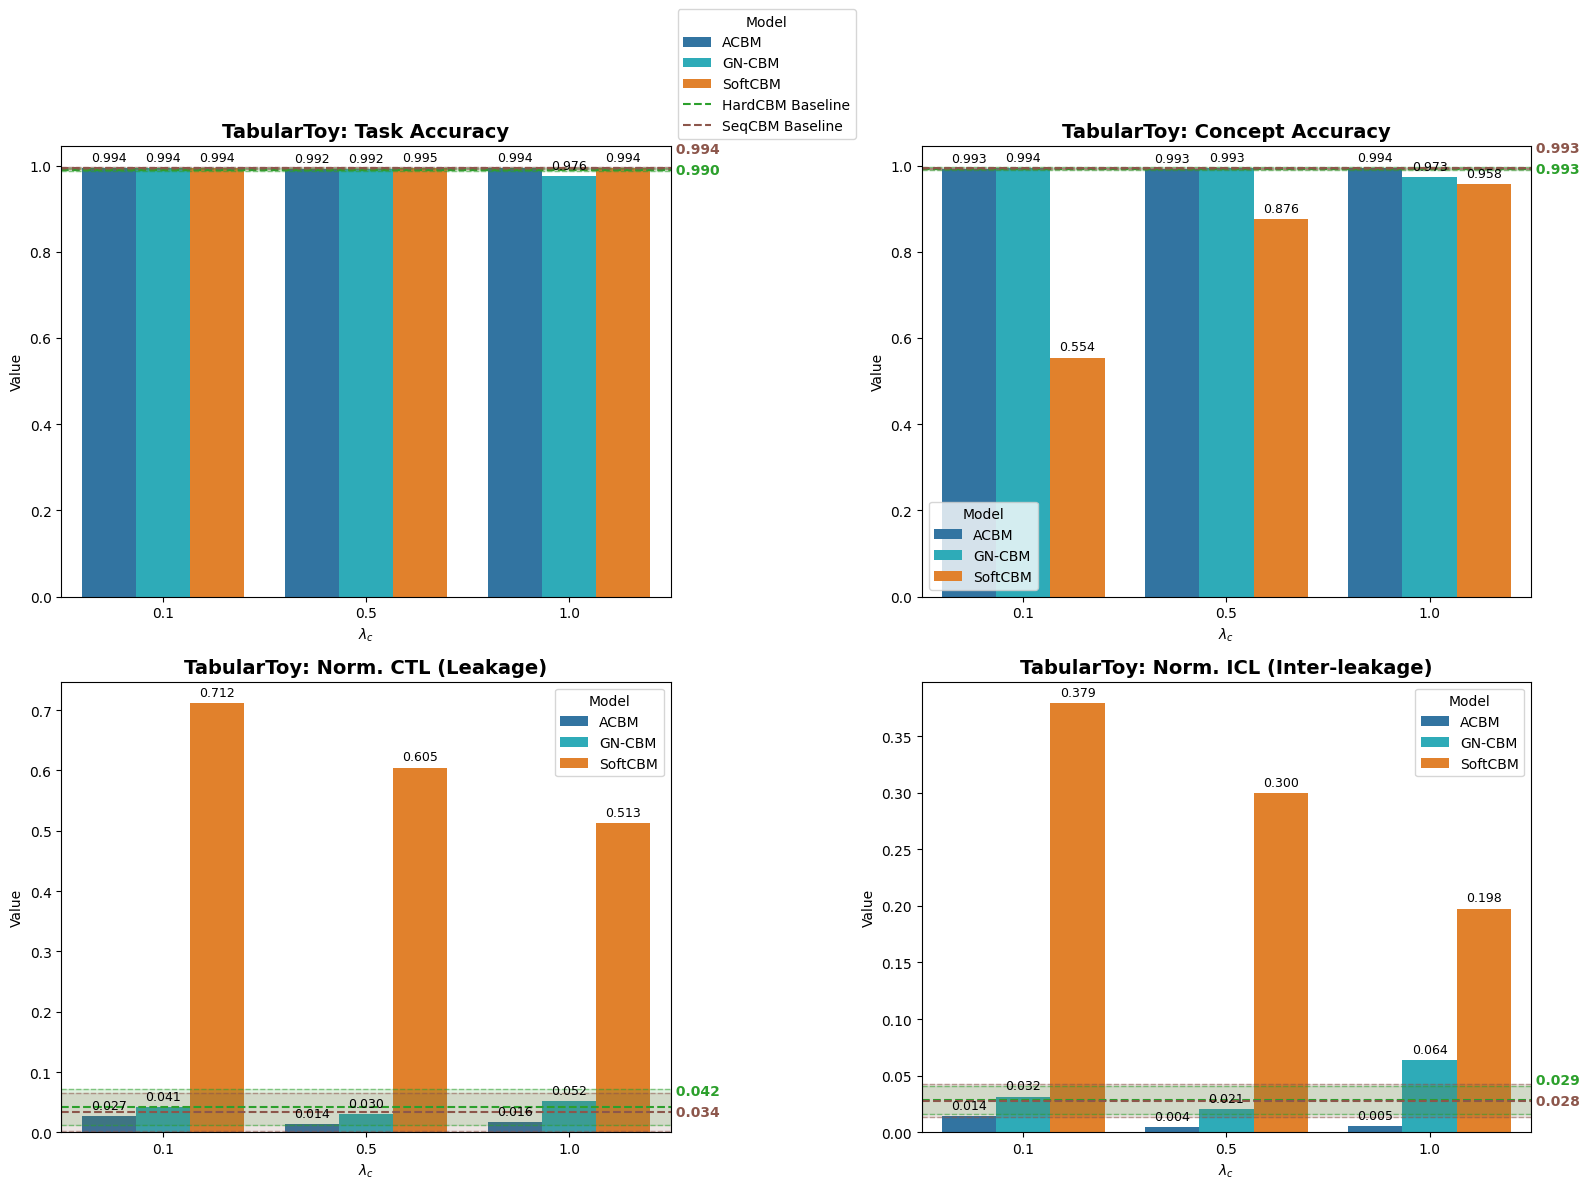

In [50]:
# Filter shared critic results: SeqCBM + ACBM with lr=0.05 only
res_tabulartoy_seq_acbm = res_tabulartoy_acbm_shared[
    res_tabulartoy_acbm_shared['filename'].apply(
        lambda f: 'SeqCBM' in f or ('shared_critic' in f and 'lr0.05' in f)
    )
].copy()
res_tabulartoy_extended = pd.concat([res_tabulartoy, res_tabulartoy_seq_acbm], ignore_index=True)
plot_bar_evaluation(res_tabulartoy_extended, models=['ACBM', 'GN-CBM', 'SoftCBM'], dataset_name='TabularToy')

Saved to saved_charts/dSprites_ACBM_GN-CBM_SoftCBM.png


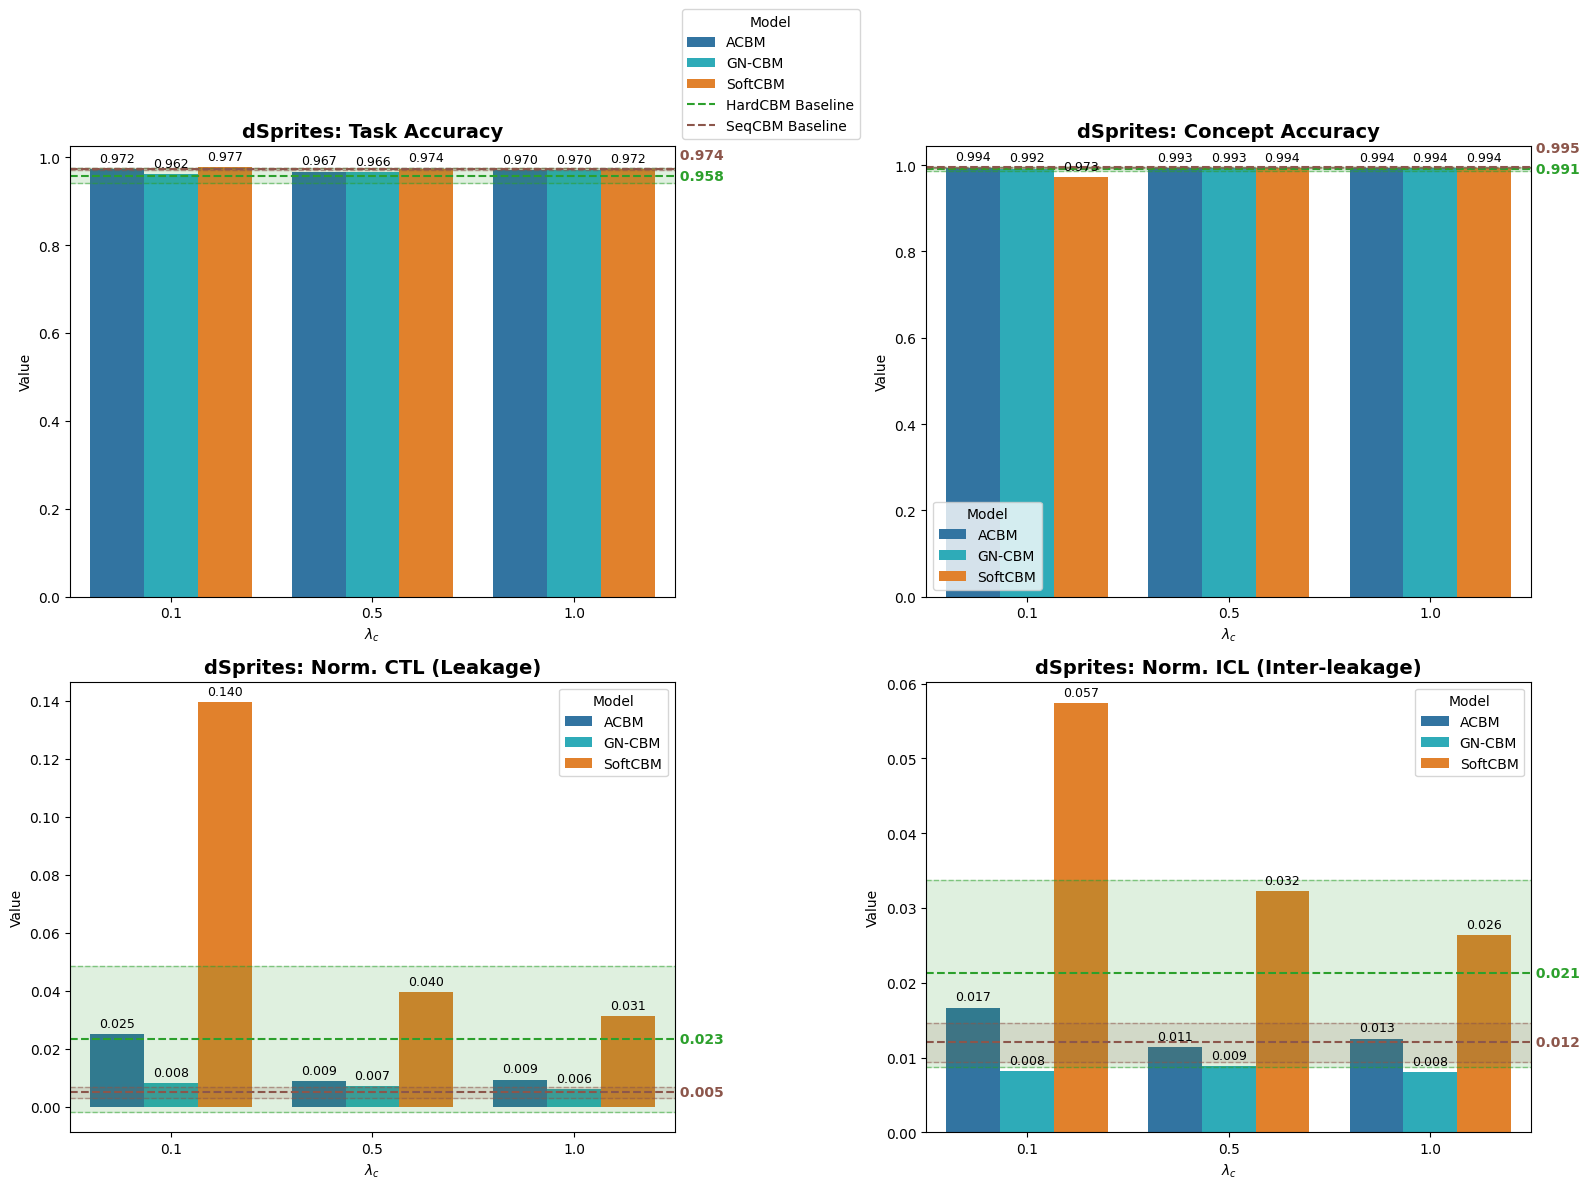

In [51]:
res_dsprites_combined = pd.concat([res_dsprites, res_dsprites_acbm, res_dsprites_sequential], ignore_index=True)
plot_bar_evaluation(res_dsprites_combined, models=['ACBM', 'GN-CBM', 'SoftCBM'], dataset_name='dSprites')

Saved to saved_charts/dSprites_GN-CEM_CEM.png


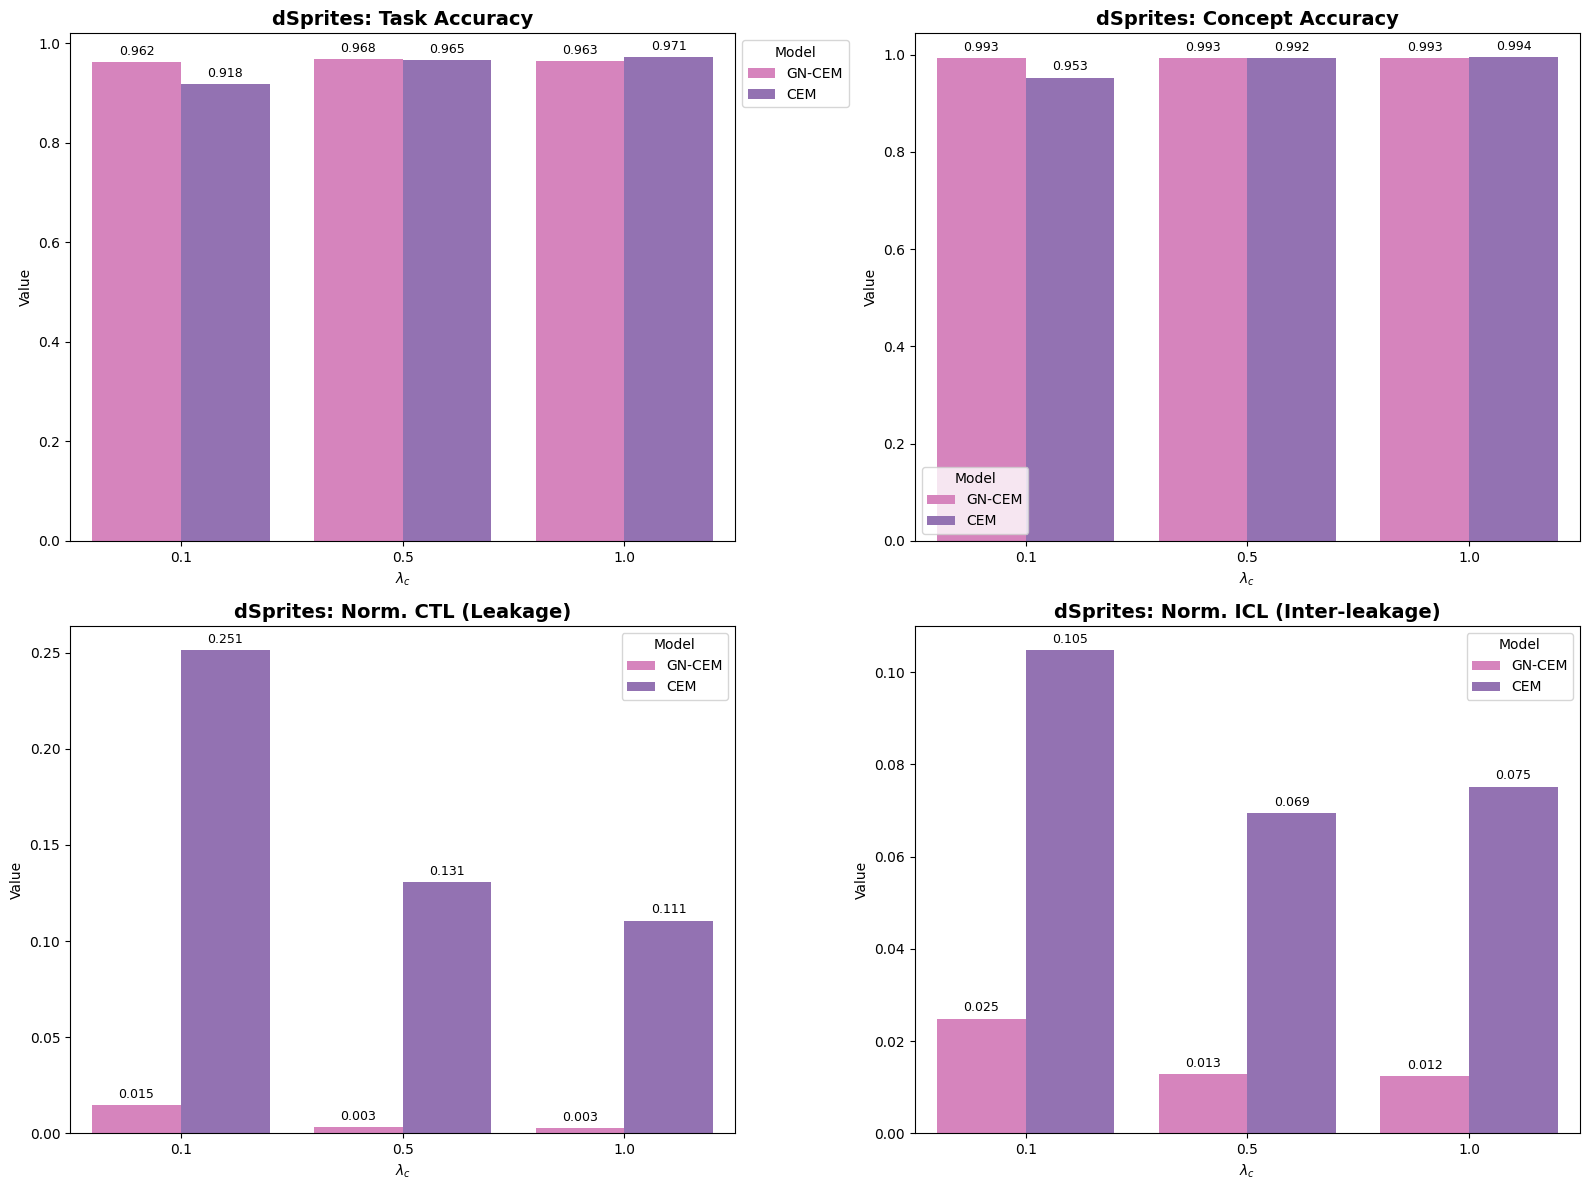

In [52]:
res_dsprites_cem_combined = pd.concat([res_dsprites_cem, res_dsprites_acem], ignore_index=True)
plot_bar_evaluation(res_dsprites_cem_combined, models=['GN-CEM', 'CEM'], dataset_name='dSprites')

Saved to saved_charts/CUB_ACBM_GN-CBM_SoftCBM.png


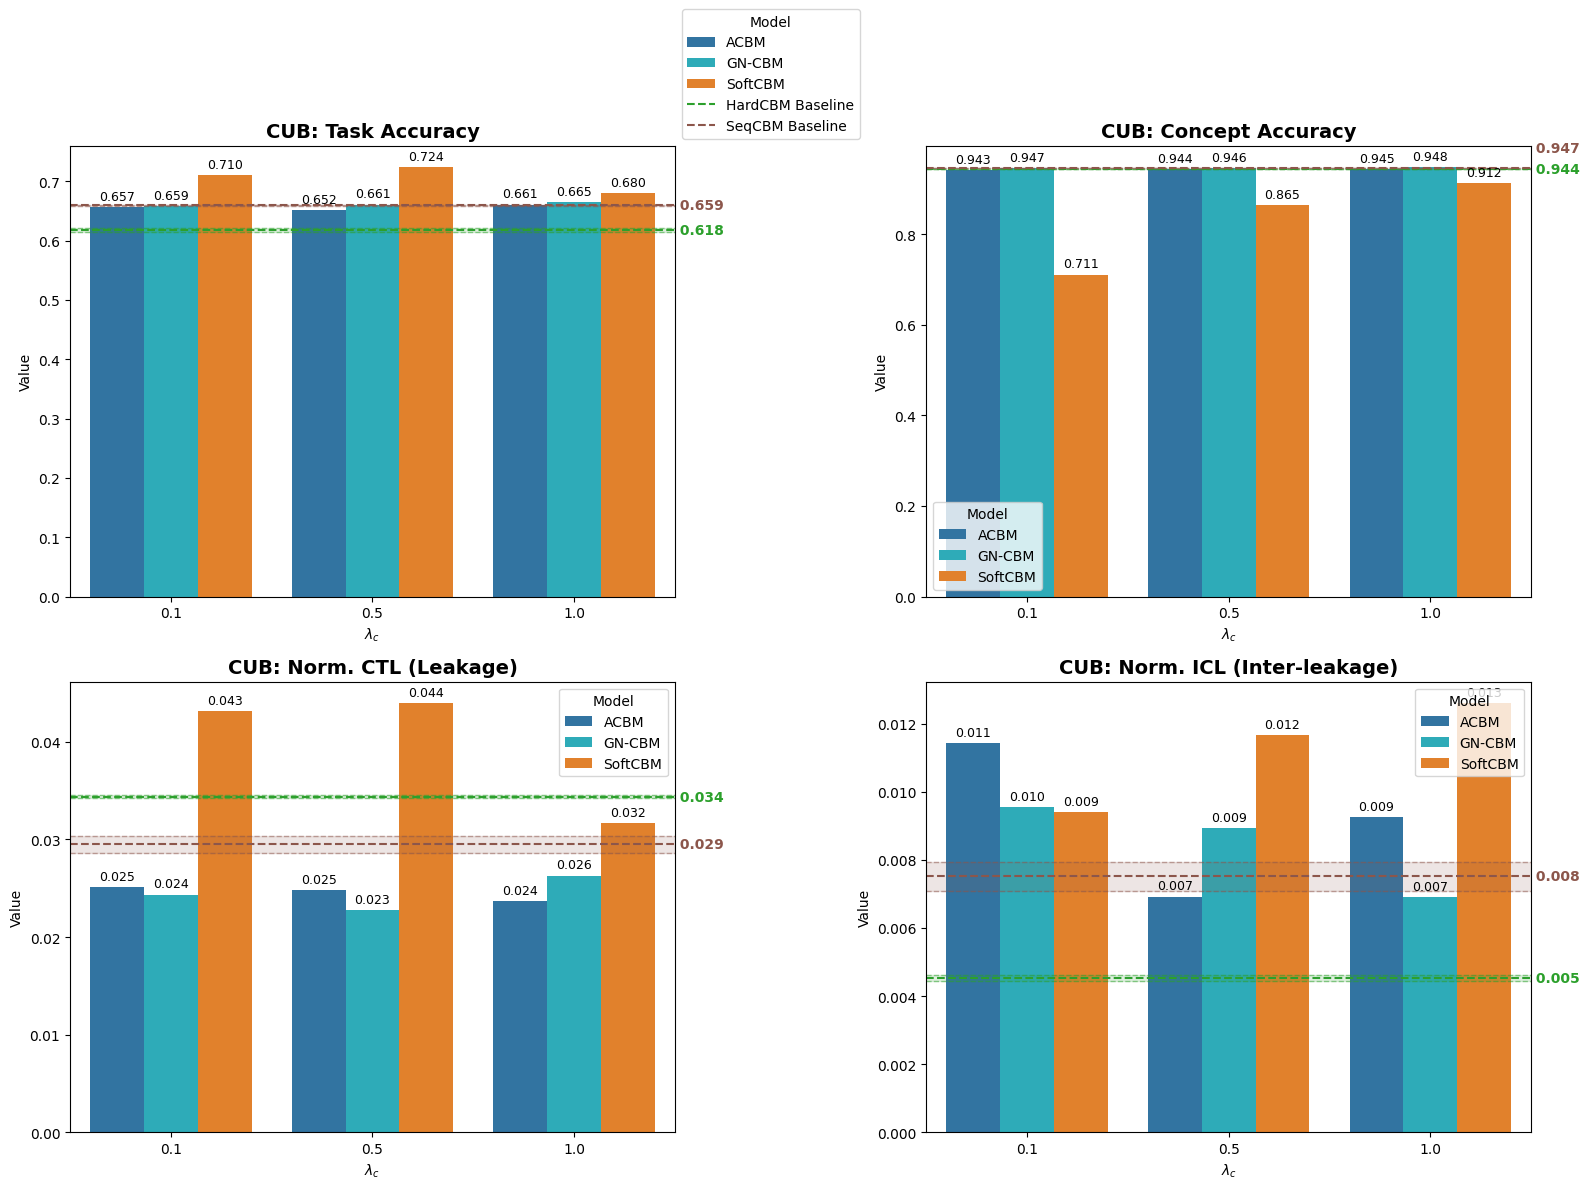

In [53]:
res_cub_combined = pd.concat([res_cub, res_cub_acbm_shared], ignore_index=True)
plot_bar_evaluation(res_cub_combined, models=['ACBM', 'GN-CBM', 'SoftCBM'], dataset_name='CUB')

Saved to saved_charts/CUB_GN-CEM_CEM.png


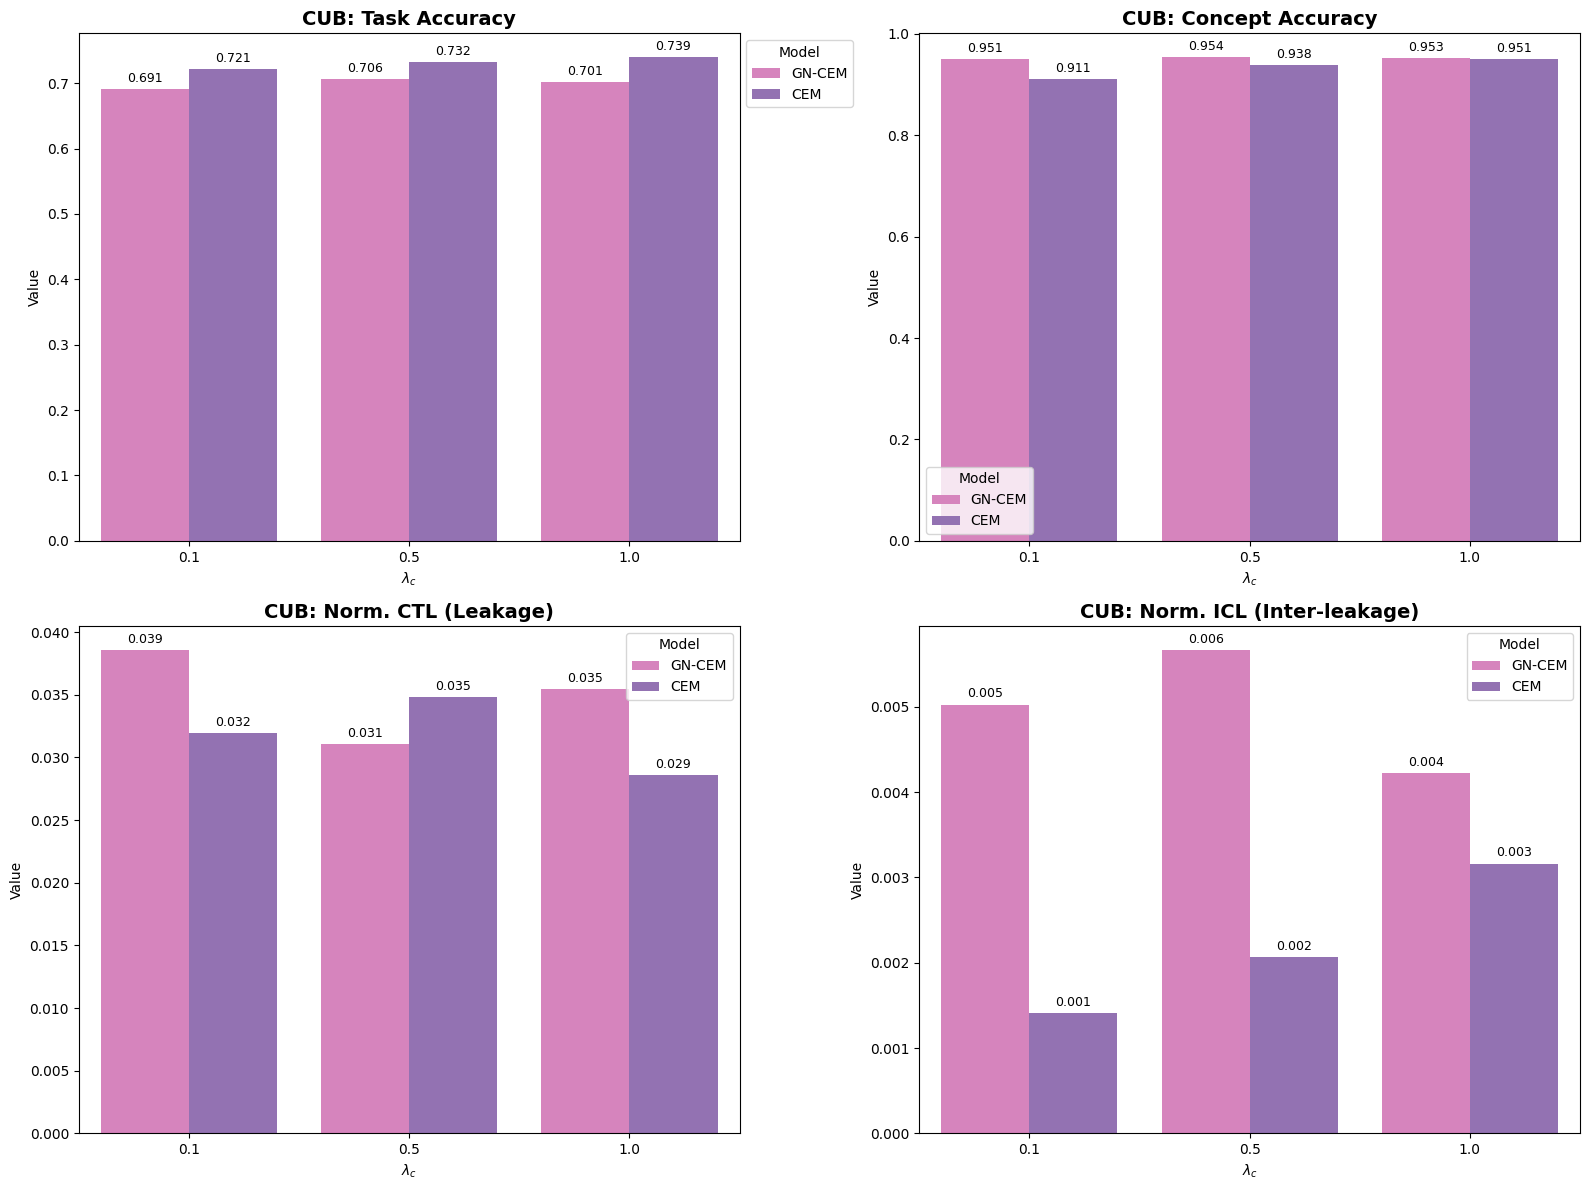

In [54]:
plot_bar_evaluation(res_cub_cem, models=['GN-CEM', 'CEM'], dataset_name='CUB')

Saved to saved_charts/TabularToy_GN-CEM_CEM.png


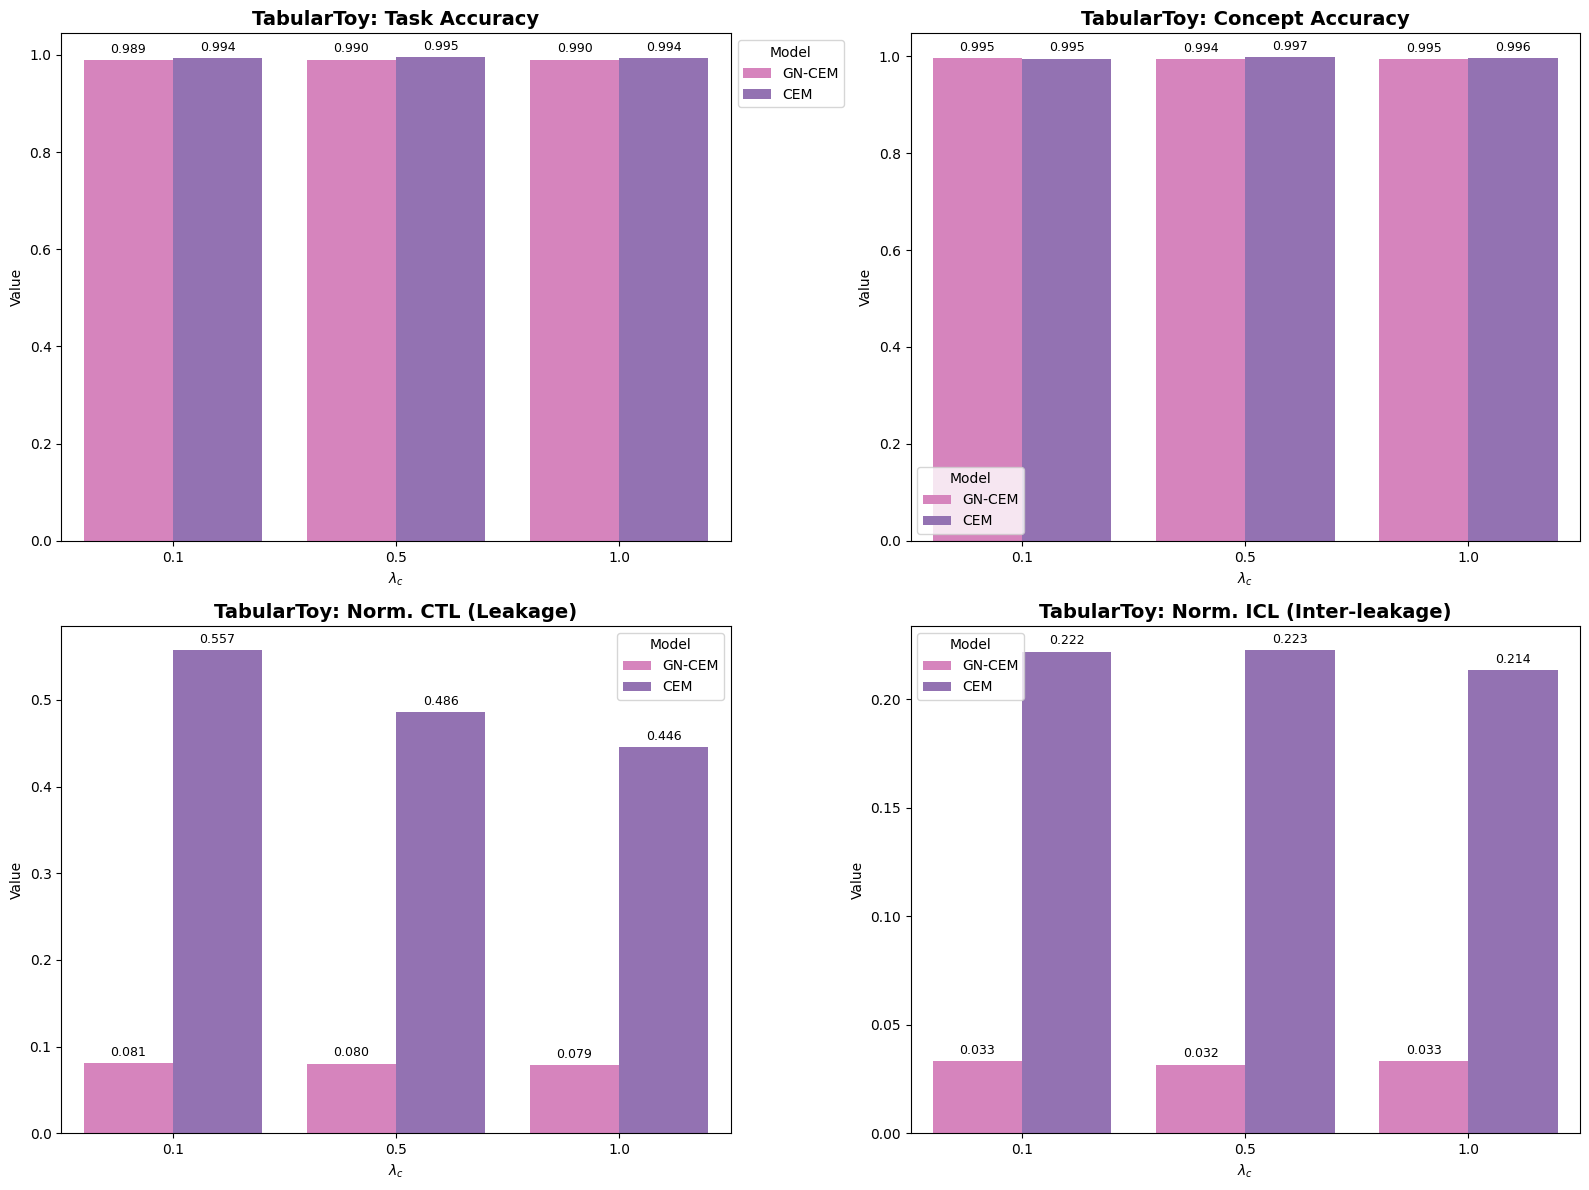

In [55]:
res_tabulartoy_cem_only = res_crcem[~res_crcem['filename'].str.contains('CRCEM', na=False)]
res_tabulartoy_cem_combined = pd.concat([res_tabulartoy_cem_only, res_tabulartoy_acem], ignore_index=True)
plot_bar_evaluation(res_tabulartoy_cem_combined, models=['GN-CEM', 'CEM'], dataset_name='TabularToy')

/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/2536767458.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend().remove()
/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/2536767458.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().remove()
/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/2536767458.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend().remove()
/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/2536767458.py:140: UserWarning: No artists with labels found to put in legend.  Note that 

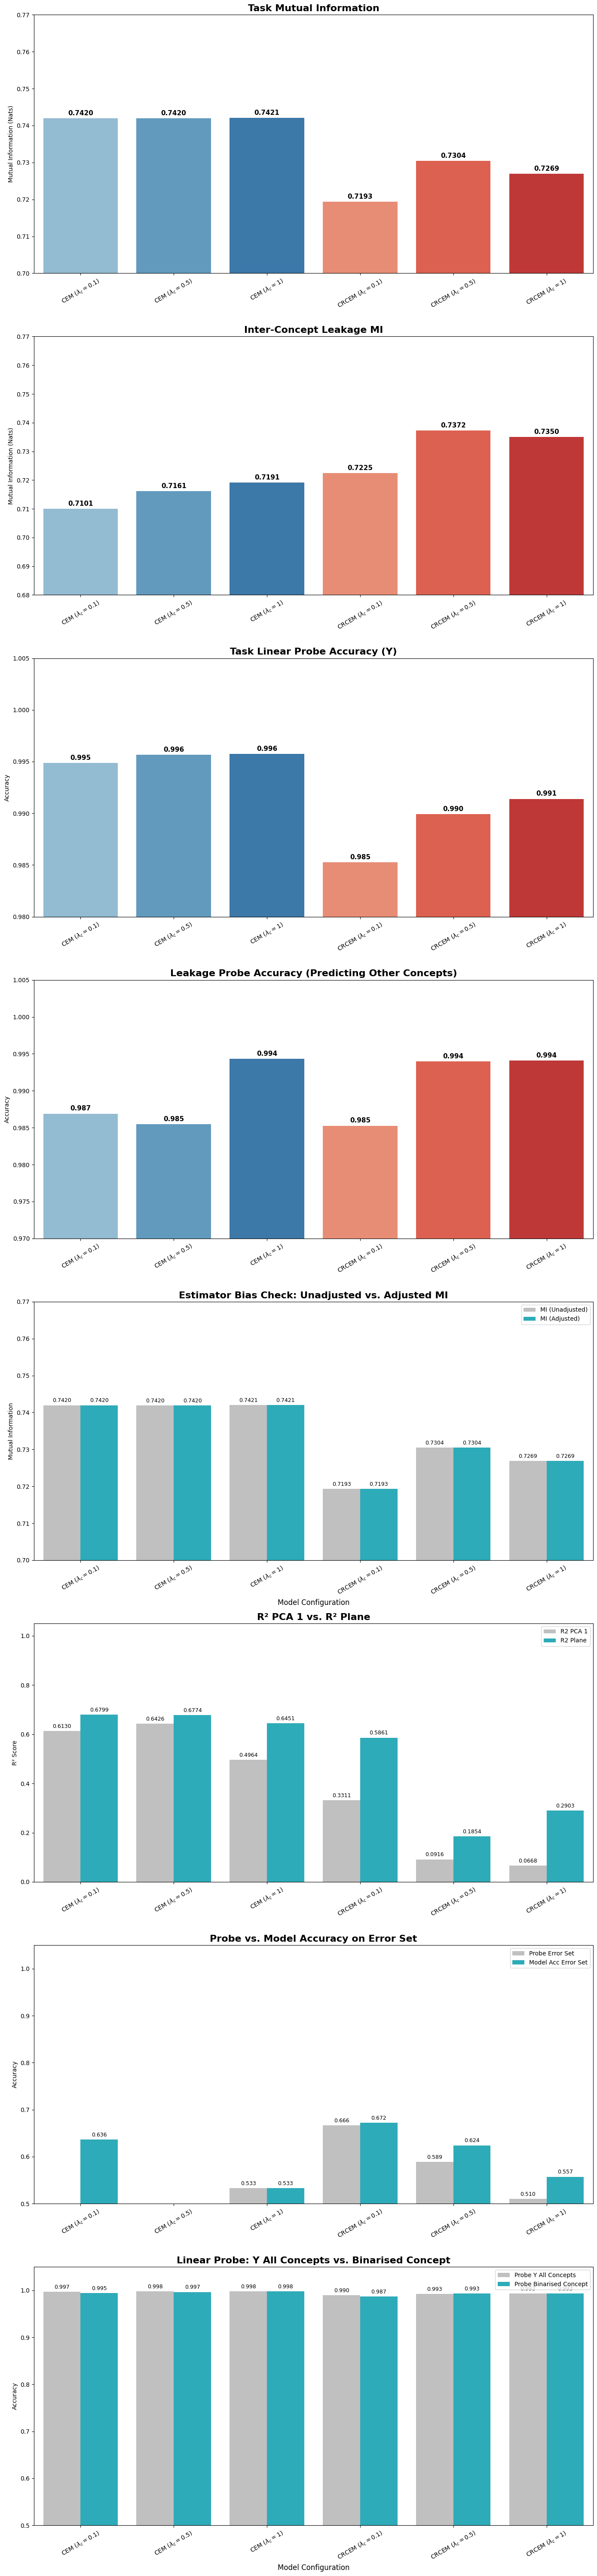

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import joblib  # Add this import if not already present

# ---------------------------------------------------------
# 1. PARSE & CALCULATE
# ---------------------------------------------------------
data_records = []
def make_pretty_name(key):
    if "CRCEM" in key and "shared_critic" in key:
        model_type = "GN-CEM"
    elif "CRCEM" in key:
        model_type = "CRCEM"
    else:
        model_type = "CEM"
    match = re.search(r'lam_c([\d\.]+)', key)
    lam_c = match.group(1) if match else "?"
    return f"{model_type} ($\lambda_c={lam_c}$)"

filename = 'results/results_tabulartoy_25_10k_crcem.dict'
d = joblib.load(filename)  # Corrected loading: joblib.load directly on filename (no with open needed)

for file_key, content in d.items():
    res = content.get('test', {})
    pretty_name = make_pretty_name(file_key)
    
    ct_mi_unadjusted = np.mean(res.get('CT_MI_mix', 0))
    ct_mi_adjusted = np.mean(res.get('CT_MI_adjusted_mix', 0))
    
    record = {
        'Model': pretty_name,
        'SortGroup': 0 if "CEM" in pretty_name and "CRCEM" not in pretty_name and "GN-CEM" not in pretty_name else 1,
        
        # Structure Metrics
        'Task MI': ct_mi_adjusted,
        'Leakage MI': np.mean(res.get('avg_other_MI_mix_c_gt', 0)),
        
        # Probe Metrics (Separated)
        'Task Probe Acc': np.mean(res.get('linear_probe_y_avg', 0)),
        'Leakage Probe Acc': np.mean(res.get('linear_probe_c_others_avg', 0)),
        
        # Bias Metrics
        'MI (Unadjusted)': ct_mi_unadjusted,
        'MI (Adjusted)': ct_mi_adjusted,
        
        # New Metrics: R2 Comparisons (assume scalar or mean if list)
        'R2 PCA 1': np.mean(res.get('R2_pca_1', 0)),
        'R2 Plane': np.mean(res.get('R2_plane', 0)),
        
        # New Metrics: Additional Probes
        'Probe Y All Concepts': np.mean(res.get('linear_probe_y_all_concept', 0)),
        'Probe Binarised Concept': np.mean(res.get('linear_probe_binarised_concept', 0)),
        
        # New Metrics: Error Set Accuracies
        'Probe Error Set': np.mean(res.get('linear_probe_error_set', 0)),
        'Model Acc Error Set': np.mean(res.get('model_acc_error_set', 0))
    }
    data_records.append(record)

df = pd.DataFrame(data_records)
df = df.sort_values(by=['SortGroup', 'Model'])

# ---------------------------------------------------------
# 2. SETUP COLORS
# ---------------------------------------------------------
unique_models = df['Model'].unique()
palette = {}
cem_colors = sns.color_palette("Blues", n_colors=6)[2:]
crcem_colors = sns.color_palette("Reds", n_colors=6)[2:]
c_idx, r_idx = 0, 0
for m in unique_models:
    if "CEM" in m and "CRCEM" not in m and "GN-CEM" not in m:
        palette[m] = cem_colors[c_idx % len(cem_colors)]
        c_idx += 1
    else:
        palette[m] = crcem_colors[r_idx % len(crcem_colors)]
        r_idx += 1

# ---------------------------------------------------------
# 3. PLOTTING (Now 8 Rows)
# ---------------------------------------------------------
# Height increased to 60 to fit 8 plots comfortably
fig, axes = plt.subplots(8, 1, figsize=(14, 60))

# --- PLOT 1: Task Mutual Information (Structure) ---
sns.barplot(
    data=df, x='Model', y='Task MI', hue='Model',
    palette=palette, ax=axes[0], dodge=False, errorbar=None
)
axes[0].set_title('Task Mutual Information', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Mutual Information (Nats)')
axes[0].set_ylim(0.70, 0.77)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend().remove()
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f', padding=3, rotation=0, fontsize=11, fontweight='bold')

# --- PLOT 2: Leakage Mutual Information (Structure) ---
sns.barplot(
    data=df, x='Model', y='Leakage MI', hue='Model',
    palette=palette, ax=axes[1], dodge=False, errorbar=None
)
axes[1].set_title('Inter-Concept Leakage MI', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Mutual Information (Nats)')
axes[1].set_ylim(0.68, 0.77)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend().remove()
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f', padding=3, rotation=0, fontsize=11, fontweight='bold')

# --- PLOT 3: Task Probe Accuracy (Utility) ---
sns.barplot(
    data=df, x='Model', y='Task Probe Acc', hue='Model',
    palette=palette, ax=axes[2], dodge=False, errorbar=None
)
axes[2].set_title('Task Linear Probe Accuracy (Y)', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0.98, 1.005)  # Specific Zoom for Task Accuracy
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend().remove()
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.3f', padding=3, rotation=0, fontsize=11, fontweight='bold')

# --- PLOT 4: Leakage Probe Accuracy (Privacy) ---
sns.barplot(
    data=df, x='Model', y='Leakage Probe Acc', hue='Model',
    palette=palette, ax=axes[3], dodge=False, errorbar=None
)
axes[3].set_title('Leakage Probe Accuracy (Predicting Other Concepts)', fontsize=16, fontweight='bold')
axes[3].set_ylabel('Accuracy')
axes[3].set_ylim(0.97, 1.005)  # Specific Zoom for Leakage Accuracy
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=30)
axes[3].legend().remove()
for container in axes[3].containers:
    axes[3].bar_label(container, fmt='%.3f', padding=3, rotation=0, fontsize=11, fontweight='bold')

# --- PLOT 5: Estimator Bias (Diff) ---
diff_metrics = ['MI (Unadjusted)', 'MI (Adjusted)']
df_diff = df.melt(id_vars=['Model'], value_vars=diff_metrics, var_name='Metric', value_name='Score')
sns.barplot(
    data=df_diff, x='Model', y='Score', hue='Metric',
    palette=['silver', '#17becf'], ax=axes[4], errorbar=None
)
axes[4].set_title('Estimator Bias Check: Unadjusted vs. Adjusted MI', fontsize=16, fontweight='bold')
axes[4].set_ylabel('Mutual Information')
axes[4].set_ylim(0.70, 0.77)
axes[4].set_xlabel('Model Configuration', fontsize=12)
axes[4].tick_params(axis='x', rotation=30)
axes[4].legend(loc='upper right')
for container in axes[4].containers:
    axes[4].bar_label(container, fmt='%.4f', padding=3, rotation=0, fontsize=9)

# --- PLOT 6: R2 PCA 1 vs. R2 Plane ---
r2_metrics = ['R2 PCA 1', 'R2 Plane']
df_r2 = df.melt(id_vars=['Model'], value_vars=r2_metrics, var_name='Metric', value_name='Score')
sns.barplot(
    data=df_r2, x='Model', y='Score', hue='Metric',
    palette=['silver', '#17becf'], ax=axes[5], errorbar=None
)
axes[5].set_title('R² PCA 1 vs. R² Plane', fontsize=16, fontweight='bold')
axes[5].set_ylabel('R² Score')
axes[5].set_ylim(0, 1.05)  # Adjust based on your data range; R² typically 0-1
axes[5].set_xlabel('')
axes[5].tick_params(axis='x', rotation=30)
axes[5].legend(loc='upper right')
for container in axes[5].containers:
    axes[5].bar_label(container, fmt='%.4f', padding=3, rotation=0, fontsize=9)

# --- PLOT 7: Probe vs. Model Acc on Error Set ---
error_metrics = ['Probe Error Set', 'Model Acc Error Set']
df_error = df.melt(id_vars=['Model'], value_vars=error_metrics, var_name='Metric', value_name='Accuracy')
sns.barplot(
    data=df_error, x='Model', y='Accuracy', hue='Metric',
    palette=['silver', '#17becf'], ax=axes[6], errorbar=None
)
axes[6].set_title('Probe vs. Model Accuracy on Error Set', fontsize=16, fontweight='bold')
axes[6].set_ylabel('Accuracy')
axes[6].set_ylim(0.5, 1.05)  # Adjust based on your data; assuming acc range
axes[6].set_xlabel('')
axes[6].tick_params(axis='x', rotation=30)
axes[6].legend(loc='upper right')
for container in axes[6].containers:
    axes[6].bar_label(container, fmt='%.3f', padding=3, rotation=0, fontsize=9)

# --- PLOT 8: Linear Probe Y All Concepts vs. Binarised Concept ---
probe_metrics = ['Probe Y All Concepts', 'Probe Binarised Concept']
df_probe = df.melt(id_vars=['Model'], value_vars=probe_metrics, var_name='Metric', value_name='Accuracy')
sns.barplot(
    data=df_probe, x='Model', y='Accuracy', hue='Metric',
    palette=['silver', '#17becf'], ax=axes[7], errorbar=None
)
axes[7].set_title('Linear Probe: Y All Concepts vs. Binarised Concept', fontsize=16, fontweight='bold')
axes[7].set_ylabel('Accuracy')
axes[7].set_ylim(0.5, 1.05)  # Adjust based on your data; assuming acc range
axes[7].set_xlabel('Model Configuration', fontsize=12)
axes[7].tick_params(axis='x', rotation=30)
axes[7].legend(loc='upper right')
for container in axes[7].containers:
    axes[7].bar_label(container, fmt='%.3f', padding=3, rotation=0, fontsize=9)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.savefig('results_8_rows_final.png', dpi=300)
plt.show()

Saved to saved_charts/pareto_frontier.png


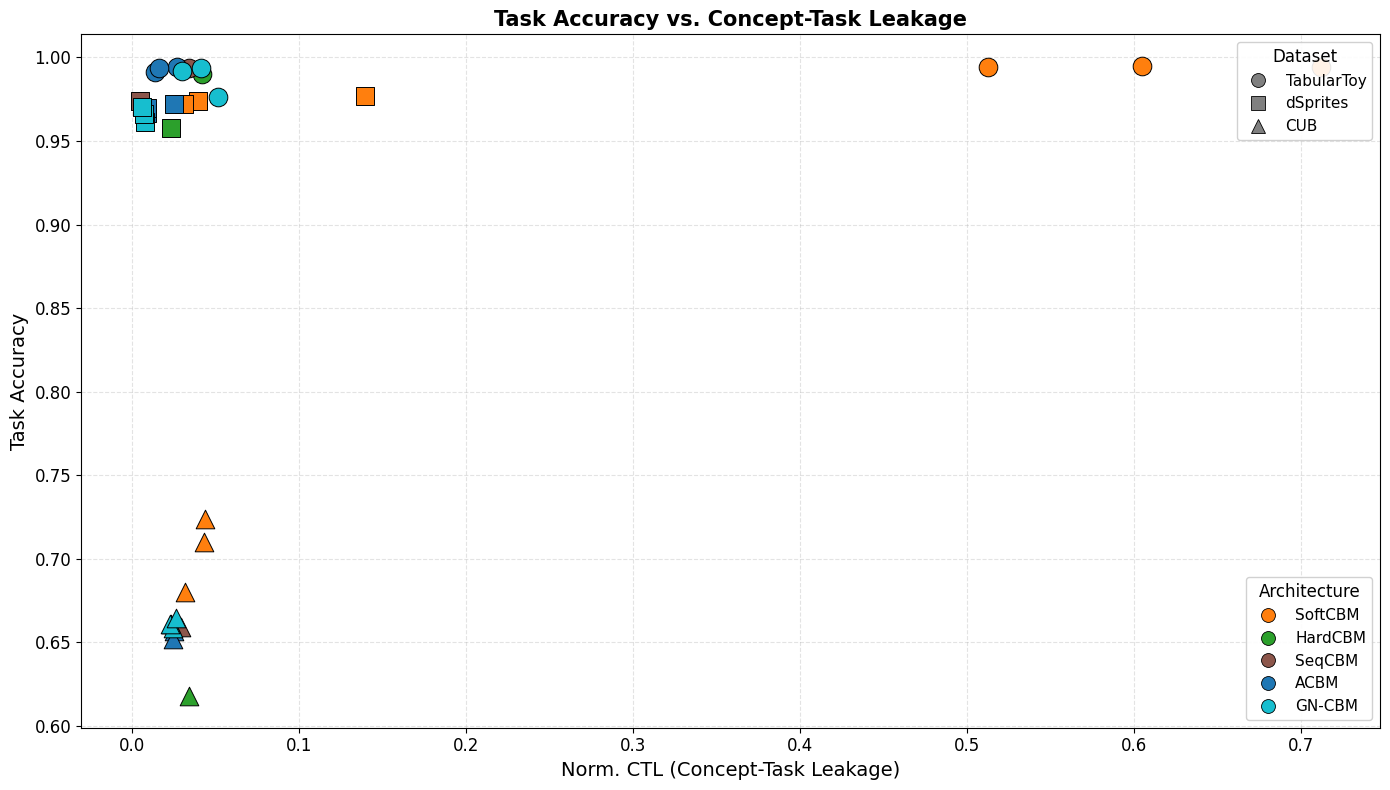

In [57]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

dataset_markers = {'TabularToy': 'o', 'dSprites': 's', 'CUB': '^'}

pareto_palette = {
    'SoftCBM':  '#ff7f0e',
    'HardCBM':  '#2ca02c',
    'SeqCBM':   '#8c564b',
    'ACBM':     '#1f77b4',
    'GN-CBM':   '#17becf',
}

def prepare_pareto_data(df, dataset_name):
    df = df.copy()
    df['Model'] = df['filename'].apply(get_model)
    if 'test_normalised_ctl' in df.columns:
        df['ctl_val'] = df['test_normalised_ctl'].fillna(df['test_ctl_average']) if 'test_ctl_average' in df.columns else df['test_normalised_ctl']
    else:
        df['ctl_val'] = df['test_ctl_average']
    if 'test_normalised_icl' in df.columns:
        df['icl_val'] = df['test_normalised_icl'].fillna(df['test_icl_average']) if 'test_icl_average' in df.columns else df['test_normalised_icl']
    else:
        df['icl_val'] = df['test_icl_average']
    agg = df.groupby(['Model', 'lam_c']).agg(
        task_acc=('test_acc_y', 'mean'),
        ctl=('ctl_val', 'mean'),
        icl=('icl_val', 'mean'),
    ).reset_index()
    agg['dataset'] = dataset_name
    return agg

# --- Assemble data ---
cub_full = pd.concat([res_cub, res_cub_acbm_shared, res_cub_cem], ignore_index=True)
tabulartoy_full = pd.concat([res_tabulartoy, res_tabulartoy_seq_acbm, res_crcem, res_tabulartoy_acem], ignore_index=True)
dsprites_full = pd.concat([res_dsprites, res_dsprites_acbm, res_dsprites_sequential,
                            res_dsprites_cem, res_dsprites_acem], ignore_index=True)

all_data = pd.concat([
    prepare_pareto_data(tabulartoy_full, 'TabularToy'),
    prepare_pareto_data(dsprites_full, 'dSprites'),
    prepare_pareto_data(cub_full, 'CUB'),
], ignore_index=True)

all_data = all_data[~all_data['Model'].isin(['CEM', 'CRCEM', 'Other'])]
all_data = all_data.dropna(subset=['ctl', 'task_acc'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 8))

for dataset, marker in dataset_markers.items():
    subset = all_data[all_data['dataset'] == dataset]
    for model, color in pareto_palette.items():
        pts = subset[subset['Model'] == model]
        if pts.empty:
            continue
        ax.scatter(
            pts['ctl'], pts['task_acc'],
            color=color, marker=marker,
            s=180, edgecolors='black', linewidth=0.7,
            zorder=3,
        )

# --- Legends ---
arch_handles = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                  markersize=10, markeredgecolor='black', markeredgewidth=0.6, label=model)
    for model, color in pareto_palette.items()
]
dataset_handles = [
    mlines.Line2D([], [], color='grey', marker=marker, linestyle='None',
                  markersize=10, markeredgecolor='black', markeredgewidth=0.6, label=dataset)
    for dataset, marker in dataset_markers.items()
]

leg1 = ax.legend(handles=arch_handles, title='Architecture', fontsize=11,
                 title_fontsize=12, loc='lower right', framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=dataset_handles, title='Dataset', fontsize=11,
          title_fontsize=12, loc='upper right', framealpha=0.9)

ax.set_xlabel('Norm. CTL (Concept-Task Leakage)', fontsize=14)
ax.set_ylabel('Task Accuracy', fontsize=14)
ax.set_title('Task Accuracy vs. Concept-Task Leakage', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
os.makedirs('saved_charts', exist_ok=True)
plt.savefig('saved_charts/pareto_frontier.png', dpi=300, bbox_inches='tight')
print("Saved to saved_charts/pareto_frontier.png")
plt.show()


In [59]:
from scipy.stats import mannwhitneyu
from itertools import product

# -----------------------------------------------------------------------
# Statistical significance: GN-CBM vs SoftCBM and GN-CBM vs SeqCBM
# Mann-Whitney U test (non-parametric, two-sided)
# Effect size: rank-biserial correlation r = 1 - 2U / (n1*n2)
# Bonferroni correction applied across all tests within each dataset
# -----------------------------------------------------------------------

METRICS = [
    ('test_acc_y',          'Task Accuracy',    'higher'),
    ('test_acc_c',          'Concept Accuracy', 'higher'),
    ('test_normalised_ctl', 'CTL (leakage)',    'lower'),
    ('test_normalised_icl', 'ICL',              'lower'),
]

DATASETS = {
    'TabularToy': res_tabulartoy_extended,
    'dSprites':   res_dsprites_combined,
    'CUB':        res_cub_combined,
}

COMPARISONS = [('GN-CBM', 'SoftCBM'), ('GN-CBM', 'SeqCBM')]

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def rank_biserial(u, n1, n2):
    return 1 - 2 * u / (n1 * n2)

all_rows = []
for dataset_name, df_raw in DATASETS.items():
    df_raw = df_raw.copy()
    df_raw['Model'] = df_raw['filename'].apply(get_model)

    # resolve CTL/ICL column names
    ctl_col = 'test_normalised_ctl' if 'test_normalised_ctl' in df_raw.columns else 'test_ctl_average'
    icl_col = 'test_normalised_icl' if 'test_normalised_icl' in df_raw.columns else 'test_icl_average'
    col_map  = {'test_normalised_ctl': ctl_col, 'test_normalised_icl': icl_col}

    n_tests = len(METRICS) * len(COMPARISONS)  # Bonferroni denominator per dataset

    for (model_a, model_b), (metric_col, metric_name, better) in product(COMPARISONS, METRICS):
        col = col_map.get(metric_col, metric_col)
        if col not in df_raw.columns:
            continue

        vals_a = df_raw[df_raw['Model'] == model_a][col].dropna().values
        vals_b = df_raw[df_raw['Model'] == model_b][col].dropna().values

        if len(vals_a) < 2 or len(vals_b) < 2:
            continue

        stat, p_raw = mannwhitneyu(vals_a, vals_b, alternative='two-sided')
        p_bonf = min(p_raw * n_tests, 1.0)
        r = rank_biserial(stat, len(vals_a), len(vals_b))

        # direction: positive r means a > b
        direction = '↓ better' if better == 'lower' else '↑ better'
        gnc_wins = (r < 0 and better == 'lower') or (r > 0 and better == 'higher')

        all_rows.append({
            'Dataset':    dataset_name,
            'Comparison': f'{model_a} vs {model_b}',
            'Metric':     metric_name,
            f'{model_a} mean': f'{vals_a.mean():.4f}',
            f'{model_b} mean': f'{vals_b.mean():.4f}',
            'Effect r':   f'{r:+.3f}',
            'p (raw)':    f'{p_raw:.4f}',
            'p (Bonf.)':  f'{p_bonf:.4f}',
            'Sig.':       sig_stars(p_bonf),
            'GN-CBM wins': '✓' if gnc_wins else '✗',
        })

results_df = pd.DataFrame(all_rows)

# Display per dataset
for dataset in ['TabularToy', 'dSprites', 'CUB']:
    sub = results_df[results_df['Dataset'] == dataset].drop(columns='Dataset')
    print(f'\n{"="*80}')
    print(f'  {dataset}')
    print(f'{"="*80}')
    display(sub.reset_index(drop=True).style
            .applymap(lambda v: 'font-weight: bold; color: green'  if v == '✓' else
                                'font-weight: bold; color: red'    if v == '✗' else '', subset=['GN-CBM wins'])
            .applymap(lambda v: 'font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.'])
            .set_caption(f'{dataset}: GN-CBM significance tests (Bonferroni-corrected, α=0.05)'))



  TabularToy


/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/4200250205.py:87: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(sub.reset_index(drop=True).style


,Comparison,Metric,GN-CBM mean,SoftCBM mean,Effect r,p (raw),p (Bonf.),Sig.,GN-CBM wins,SeqCBM mean
0,GN-CBM vs SoftCBM,Task Accuracy,0.9845,0.9945,+0.410,0.0398,0.3188,ns,✓,nan
1,GN-CBM vs SoftCBM,Concept Accuracy,0.9835,0.7960,-0.903,0.0000,0.0001,***,✗,nan
2,GN-CBM vs SoftCBM,CTL (leakage),0.0438,0.6096,+1.000,0.0000,0.0000,***,✗,nan
3,GN-CBM vs SoftCBM,ICL,0.0450,0.2922,+0.907,0.0000,0.0001,***,✗,nan
4,GN-CBM vs SeqCBM,Task Accuracy,0.9845,nan,+0.250,0.4094,1.0000,ns,✓,0.9940
5,GN-CBM vs SeqCBM,Concept Accuracy,0.9835,nan,-0.410,0.1741,1.0000,ns,✗,0.9935
6,GN-CBM vs SeqCBM,CTL (leakage),0.0438,nan,-0.140,0.6685,1.0000,ns,✓,0.0342
7,GN-CBM vs SeqCBM,ICL,0.0450,nan,+0.140,0.6685,1.0000,ns,✗,0.0279



  dSprites


/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/4200250205.py:87: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(sub.reset_index(drop=True).style


,Comparison,Metric,GN-CBM mean,SoftCBM mean,Effect r,p (raw),p (Bonf.),Sig.,GN-CBM wins,SeqCBM mean
0,GN-CBM vs SoftCBM,Task Accuracy,0.9660,0.9745,+0.893,0.0000,0.0003,***,✓,nan
1,GN-CBM vs SoftCBM,Concept Accuracy,0.9931,0.9871,+0.156,0.4807,1.0000,ns,✓,nan
2,GN-CBM vs SoftCBM,CTL (leakage),0.0071,0.0701,+1.000,0.0000,0.0000,***,✗,nan
3,GN-CBM vs SoftCBM,ICL,0.0084,0.0387,+1.000,0.0000,0.0000,***,✗,nan
4,GN-CBM vs SeqCBM,Task Accuracy,0.9660,nan,+0.973,0.0016,0.0132,*,✓,0.9740
5,GN-CBM vs SeqCBM,Concept Accuracy,0.9931,nan,+0.973,0.0017,0.0134,*,✓,0.9948
6,GN-CBM vs SeqCBM,CTL (leakage),0.0071,nan,-0.227,0.4973,1.0000,ns,✓,0.0050
7,GN-CBM vs SeqCBM,ICL,0.0084,nan,+0.813,0.0054,0.0433,*,✗,0.0120



  CUB


/var/folders/s_/7nkzs5sd5ls5crvh1z51_7z40000gn/T/ipykernel_29167/4200250205.py:87: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(sub.reset_index(drop=True).style


,Comparison,Metric,GN-CBM mean,SoftCBM mean,Effect r,p (raw),p (Bonf.),Sig.,GN-CBM wins,SeqCBM mean
0,GN-CBM vs SoftCBM,Task Accuracy,0.6613,0.7045,+1.000,0.0000,0.0000,***,✓,nan
1,GN-CBM vs SoftCBM,Concept Accuracy,0.9470,0.8294,-1.000,0.0000,0.0000,***,✗,nan
2,GN-CBM vs SoftCBM,CTL (leakage),0.0245,0.0396,+1.000,0.0000,0.0000,***,✗,nan
3,GN-CBM vs SoftCBM,ICL,0.0085,0.0112,+0.742,0.0006,0.0046,**,✗,nan
4,GN-CBM vs SeqCBM,Task Accuracy,0.6613,nan,-0.227,0.4848,1.0000,ns,✗,0.6594
5,GN-CBM vs SeqCBM,Concept Accuracy,0.9470,nan,-0.253,0.4445,1.0000,ns,✗,0.9466
6,GN-CBM vs SeqCBM,CTL (leakage),0.0245,nan,+1.000,0.0001,0.0010,**,✗,0.0295
7,GN-CBM vs SeqCBM,ICL,0.0085,nan,-0.147,0.6725,1.0000,ns,✓,0.0075
